In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import classification_report, mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.optim as optim


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


In [49]:

# 1) Load preprocessed frame‐level features (wide) and play outcomes
raw_features = pd.read_csv("../data/play_features.csv")
outcomes = pd.read_csv("../data/play_outcomes.csv")
features = raw_features.rename(columns={"gameId":"game_id","playId":"play_id","frameId":"frame_id"})


C:\Users\jesse\AppData\Local\Temp\ipykernel_8300\41615355.py:2: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,14,15,16,17,18,19,20,21,22,25,26,27,28,29,30,31,32,33,36,37,38,39,40,41,42,43,44,47,48,49,50,51,52,53,54,55,58,59,60,61,62,63,64,65,66,69,70,71,72,73,74,75,76,77,80,81,82,83,84,85,86,87,88,91,92,93,94,95,96,97,98,99,102,103,104,105,106,107,108,109,110,113,114,115,116,117,118,119,120,121,124,125,126,127,128,129,130,131,132,135,136,137,138,139,140,141,142,143,146,147,148,149,150,151,152,153,154,157,158,159,160,161,162,163,164,165,168,169,170,171,172,173,174,175,176,179,180,181,182,183,184,185,186,187,190,191,192,193,194,195,196,197,198,201,202,203,204,205,206,207,208,209,212,213,214,215,216,217,218,219,220,223,224,225,226,227,228,229,230,231,234,235,236,237,238,239,240,241,242,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_features = pd.read_csv("../data/play_features.csv")


In [50]:
# features.loc[[36864]]["player_0_nflId"].item()
test = features[["player_0_nflId"]]
features = features[  test.apply(lambda row: any(isinstance(item, float) for item in row), axis=1)]
outcomes = outcomes[outcomes["game_id"] != "game_id"]

In [51]:
# # fix the line of scrimmage and relative x mistakes
# # Step 1: Recalculate LOS as 10 yards behind the football (assumes player_22 is always the football)
# features['los'] = features['los'] - 10

# # Step 2: Recalculate x_relative for every player
# for i in range(23):  # Players 0 through 22
#     features[f'player_{i}_x_relative'] = features[f'player_{i}_x'] - features['los'] - 10


In [52]:
outcomes[outcomes["pass_result"] == "R"]

,game_id,play_id,start_frame,end_frame,play_type,down,yards_to_go,line_of_scrimmage,yards_gained,pass_result,targeted_receiver_nflId,time_to_throw
35,2022091105,4373,102,152,R,2,10,69,10,R,NaN,NaN
53,2022091101,1192,155,202,R,1,10,42,2,R,NaN,NaN
71,2022091108,3396,96,103,R,1,10,26,4,R,NaN,7.0
78,2022090800,2464,111,145,R,1,15,94,8,R,NaN,NaN
84,2022091109,1544,58,92,R,1,9,9,6,R,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9643,2022110608,360,112,168,R,3,5,78,21,R,NaN,NaN
9653,2022110603,3064,72,134,R,3,17,64,18,R,NaN,NaN
9702,2022110610,306,131,165,R,2,15,39,16,R,NaN,NaN
9720,2022110300,2926,122,159,R,2,6,54,7,R,NaN,NaN


In [53]:
# Step 1: Recalculate LOS as 10 yards behind the football (assumes player_22 is always the football)
raw_features.head(5)

,player_0_nflId,player_0_displayName_x,player_0_position,player_0_x,player_0_x_relative,player_0_y,player_0_s,player_0_a,player_0_dis,player_0_o,...,player_22_a,player_22_dis,player_22_o,player_22_dir,gameId,playId,frameId,yards_to_go,down,los
0,52461.0,Jalen Hurts,QB,40.08,-4.92,28.4,0.17,0.24,0.04,98.31,...,0.0,0.0,NaN,NaN,2022091104,3662,106,12,3,65
1,52461.0,Jalen Hurts,QB,40.04,-4.96,28.38,0.25,0.18,0.04,99.04,...,0.0,0.0,NaN,NaN,2022091104,3662,107,12,3,65
2,52461.0,Jalen Hurts,QB,40.0,-5.0,28.36,0.35,0.45,0.05,105.12,...,1.49,2.2,NaN,NaN,2022091104,3662,108,12,3,65
3,52461.0,Jalen Hurts,QB,39.94,-5.06,28.34,0.49,0.96,0.06,108.84,...,3.33,0.8,NaN,NaN,2022091104,3662,109,12,3,65
4,52461.0,Jalen Hurts,QB,39.86,-5.14,28.32,0.74,1.78,0.08,118.12,...,4.9,0.77,NaN,NaN,2022091104,3662,110,12,3,65


array([52461.0, 29851.0, 52414.0, 43291.0, 53430.0, 43290.0, 46070.0,
       41265.0, 44822.0, 33099.0, 52413.0, 43424.0, 33084.0, 44814.0,
       25511.0, 43380.0, 52409.0, 46076.0, 42344.0, 47789.0, 53440.0,
       45536.0, 46101.0, 53432.0, 42345.0, 38605.0, 39987.0, 52434.0,
       53496.0, 38538.0, 34452.0, 53444.0, 47784.0, 47980.0, 38632.0,
       43496.0, '43290.0', '53444.0', '41265.0', '46070.0', '34452.0',
       '53496.0', '43424.0', '33099.0', '44822.0', '39987.0', '52409.0',
       '53430.0', '38632.0', '47784.0', '43291.0', '53432.0', '53440.0',
       '52413.0', '52461.0', '25511.0', '42344.0', '45536.0', '52414.0',
       '44814.0', '43380.0', '29851.0', '33084.0', '38605.0', '46076.0',
       'player_0_nflId', 41291.0, 54551.0, 38937.0, '42345.0', '41258.0',
       '46101.0', '38538.0', '47789.0', '41291.0', 41258.0, '37110.0',
       54485.0, 53431.0, 37110.0, 37255.0, 54602.0, 34843.0, '54712.0',
       '54485.0', '54602.0', '38937.0', 54712.0, 45159.0, '45244.0',
 

In [ ]:
raw_features[raw_features["player_0_position"] == "WR"]["player_11_displayName_x"].value_counts()

player_11_displayName_x
Nick Westbrook-Ikhine    19
Name: count, dtype: int64

player_0_nflId
player_0_displayName_x
player_0_position
player_0_x
player_0_x_relative
player_0_y
player_0_s
player_0_a
player_0_dis
player_0_o
player_0_dir
player_1_nflId
player_1_displayName_x
player_1_position
player_1_x
player_1_x_relative
player_1_y
player_1_s
player_1_a
player_1_dis
player_1_o
player_1_dir
player_2_nflId
player_2_displayName_x
player_2_position
player_2_x
player_2_x_relative
player_2_y
player_2_s
player_2_a
player_2_dis
player_2_o
player_2_dir
player_3_nflId
player_3_displayName_x
player_3_position
player_3_x
player_3_x_relative
player_3_y
player_3_s
player_3_a
player_3_dis
player_3_o
player_3_dir
player_4_nflId
player_4_displayName_x
player_4_position
player_4_x
player_4_x_relative
player_4_y
player_4_s
player_4_a
player_4_dis
player_4_o
player_4_dir
player_5_nflId
player_5_displayName_x
player_5_position
player_5_x
player_5_x_relative
player_5_y
player_5_s
player_5_a
player_5_dis
player_5_o
player_5_dir
player_6_nflId
player_6_displayName_x
player_6_position
pl

In [13]:
for col in features.select_dtypes(include=['object']).columns:
    features[col] = pd.to_numeric(features[col], errors='coerce')

for col in ["game_id", "play_id", "targeted_receiver_nflId", "start_frame", "end_frame", "down",	"yards_to_go",	"line_of_scrimmage",	"yards_gained","time_to_throw" ]:
    outcomes[col] = pd.to_numeric(outcomes[col], errors='coerce')


In [14]:

# Merge outcomes onto features
test_df = features.merge(outcomes[["game_id", "play_id", "targeted_receiver_nflId"]], on=["game_id", "play_id"])

# Get receiver index (0–5 for players 5–10)
def get_receiver_index(row):
    for i in range(6, 11):  # player_5 to player_10
        if row[f"player_{i}_nflId"] == row["targeted_receiver_nflId"]:
            return i - 6 
    return -1  # not found

test_df["target_receiver_index"] = test_df.apply(get_receiver_index, axis=1)
features = test_df[test_df["target_receiver_index"] != -1]  # Keep only valid rows
test_df[[ "player_6_nflId", "player_7_nflId", "player_8_nflId", "player_9_nflId", "player_10_nflId", "targeted_receiver_nflId", "target_receiver_index"]]
# test_df[["player5_position", "player6_position", "player7_position", "player8_position", "player9_position", "player10_position", "targeted_receiver_nflId", "target_receiver_index"]]
# test_df[test_df["target_receiver_index"] == -1].drop_duplicates(subset=["game_id", "play_id"]) #these are plays with no receiver


,player_6_nflId,player_7_nflId,player_8_nflId,player_9_nflId,player_10_nflId,targeted_receiver_nflId,target_receiver_index
0,53579.0,46118.0,45102.0,47834.0,53439.0,53439.0,4
1,53579.0,46118.0,45102.0,47834.0,53439.0,53439.0,4
2,53579.0,46118.0,45102.0,47834.0,53439.0,53439.0,4
3,53579.0,46118.0,45102.0,47834.0,53439.0,53439.0,4
4,53579.0,46118.0,45102.0,47834.0,53439.0,53439.0,4
...,...,...,...,...,...,...,...
278177,53454.0,44835.0,38696.0,44849.0,46116.0,44835.0,1
278178,53454.0,44835.0,38696.0,44849.0,46116.0,44835.0,1
278179,53454.0,44835.0,38696.0,44849.0,46116.0,44835.0,1
278180,53454.0,44835.0,38696.0,44849.0,46116.0,44835.0,1


In [15]:
def add_target_onehot(X, target_idx_col):
    target_onehot = np.zeros((len(X), 5))
    target_indices = X[target_idx_col].values.astype(int)
    for i, idx in enumerate(target_indices):
        target_onehot[i, idx] = 1
    return np.concatenate([X.drop(columns=[target_idx_col]).values, target_onehot], axis=1)

add_target_onehot(test_df.head(1), "target_receiver_index")

array([[ 5.24610000e+04,             nan,             nan,
         4.00800000e+01, -4.92000000e+00,  2.84000000e+01,
         1.70000000e-01,  2.40000000e-01,  4.00000000e-02,
         9.83100000e+01,  2.29070000e+02,  3.72660000e+04,
                    nan,             nan,  4.47000000e+01,
        -3.00000000e-01,  2.83900000e+01,  2.80000000e-01,
         7.80000000e-01,  3.00000000e-02,  4.95900000e+01,
         1.09600000e+01,  4.33680000e+04,             nan,
                    nan,  4.41300000e+01, -8.70000000e-01,
         2.70700000e+01,  8.00000000e-02,  6.10000000e-01,
         0.00000000e+00,  3.93600000e+01,  1.42550000e+02,
         5.34660000e+04,             nan,             nan,
         4.40800000e+01, -9.20000000e-01,  2.96700000e+01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         7.70500000e+01,  1.09900000e+02,  3.99500000e+04,
                    nan,             nan,  4.38700000e+01,
        -1.13000000e+00,  2.51400000e+01,  0.00000000e+0

In [16]:
features["los"].min()

1

In [17]:
# Merge end_frame into features
features = features.merge(
    outcomes[["game_id", "play_id", "end_frame"]],
    on=["game_id", "play_id"],
    how="left"
)

# Filter to only the final frame of each play
last_frame_features = features[features["frame_id"] == features["end_frame"]].copy()

# Optionally, drop 'end_frame' if not needed anymore
last_frame_features.drop(columns=["end_frame"], inplace=True)
features = last_frame_features


In [18]:


# Attributes to extract from the targeted receiver
receiver_attrs = ['x', 'x_relative', 'y', 's', 'a', 'dis', 'o', 'dir']
targeted_features = []

for idx, row in features.iterrows():
    target_idx = int(row['target_receiver_index'])

    if 0 <= target_idx <= 4:
        # Extract receiver features from row
        features_row = [row.get(f'player_{target_idx + 6}_{attr}', 0.0) for attr in receiver_attrs]
    else:
        # Use zero padding if no targeted receiver
        features_row = [0.0] * len(receiver_attrs)

    targeted_features.append(features_row)

# Create the new target feature columns
targeted_df = pd.DataFrame(targeted_features, columns=[f'target_{attr}' for attr in receiver_attrs])

# Combine with the original features DataFrame
features = pd.concat([features.reset_index(drop=True), targeted_df], axis=1)


In [19]:
features[["target_x_relative", "target_receiver_index", "player_6_x_relative", "player_7_x_relative", "player_8_x_relative", "player_9_x_relative", "player_10_x_relative"]]

,target_x_relative,target_receiver_index,player_6_x_relative,player_7_x_relative,player_8_x_relative,player_9_x_relative,player_10_x_relative
0,0.09,4,-4.35,2.69,3.23,2.80,0.09
1,24.65,2,3.01,7.67,24.65,24.20,15.06
2,17.22,3,1.29,2.46,-9.21,17.22,15.55
3,-4.16,2,-4.56,-1.95,-4.16,1.93,0.50
4,1.03,1,-3.00,1.03,-2.56,7.23,5.54
...,...,...,...,...,...,...,...
7891,0.94,1,-3.34,0.94,13.84,20.50,8.68
7892,-3.33,1,-4.68,-3.33,-0.36,-0.90,1.03
7893,2.92,1,-0.73,2.92,2.62,4.45,5.00
7894,4.29,3,0.92,11.48,15.16,4.29,4.91


In [20]:

# features_with_outcomes = features.merge(outcomes[['game_id', 'play_id', 'start_frame', 'end_frame']], 
#                                         on=['game_id', 'play_id'], how='left')

# # Step 2: Check if frame_ids in features are within the start_frame and end_frame
# misaligned = features_with_outcomes[
#     (features_with_outcomes['frame_id'] < features_with_outcomes['start_frame']) |
#     (features_with_outcomes['frame_id'] > features_with_outcomes['end_frame'])
# ]

# if not misaligned.empty:
#     print(f"Warning: Found {len(misaligned)} misaligned frames")
# else:
#     print("All frames in features are within the start and end frames of their respective plays.")


In [21]:
outcomes = outcomes[outcomes["pass_result"].isin(["I", "IN", "C"])]
# Step 3: Merge all outcome columns into features
features = features.merge(outcomes, on=['game_id', 'play_id'], how='left')



# Step 5: Create new feature: frames from snap
features['frames_from_snap'] = features['frame_id'] - features['start_frame']

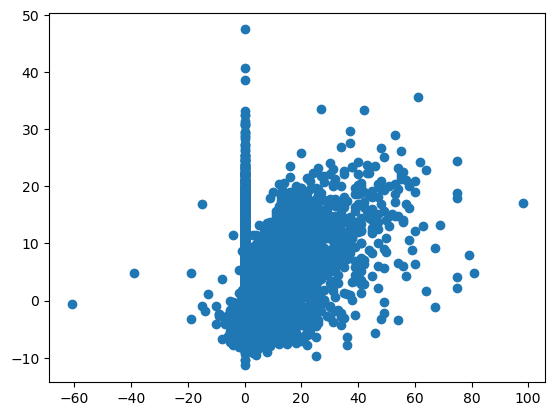

In [22]:
plt.scatter(features[["yards_gained"]], features[[ "target_x_relative"]])

In [23]:
# 3) Build X, y for two tasks:
#   a) Classification: pass_result (C vs I vs IN)
#   b) Regression: yards_gained

# a) Classification target
# Drop columns that start with 'name_' or 'jersey_', and also 'start_frame' and 'end_frame'
cols_to_drop = [col for col in features.columns 
                if col.endswith('Name_x') or col.endswith('nflId') or col.endswith('displayName_y') or col.endswith('_position')
                or col in ['start_frame', 'end_frame', "game_id","play_id","frame_id","yards_gained","play_type",
                           "pass_result","player22_nflId","targeted_receiver","time_to_throw", "player22_o", 'player_22_nflId',
                           'player_22_position', 'player_22_o', 'player_22_dir'	, 'time_to_throw',
                           "player22_dir",	"player22_position",	"player22_displayName_y"]]

# [2022091104,3662,37266.0,Jason Kelce,106,SNAP,2022-09-11 19:47:01.7,62.0,PHI,right,44.7,28.39,0.28,0.78,0.03,49.59,10.96,ball_snap,C,Jason Kelce]

clf_df = features.dropna(subset=["pass_result"]).copy()
X_clf = clf_df.drop(columns=cols_to_drop)
y_clf = clf_df["pass_result"]
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)  # e.g. ['C','I','IN']→[0,1,2]

# b) Regression target
reg_df = features[features["pass_result"] == 'C'].copy()

X_reg = reg_df.drop(columns=cols_to_drop)
y_reg = reg_df["yards_gained"]

(array([2419.,    0.,    0.,    0.,    0.,  177.,    0.,    0.,    0.,
        5299.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

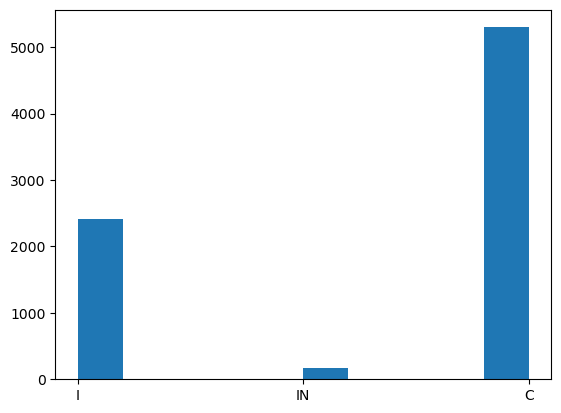

In [24]:
plt.hist(y_clf)

In [25]:

# 4) Train/test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf_enc, test_size=0.2, random_state=42, stratify=y_clf_enc
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [26]:
# Xc_train.iloc[:, 30:50].dtypes
yc_train.shape
type(Xc_train)

pandas.core.frame.DataFrame

In [27]:

for i in outcomes.columns:
  print(i)


game_id
play_id
start_frame
end_frame
play_type
down
yards_to_go
line_of_scrimmage
yards_gained
pass_result
targeted_receiver_nflId
time_to_throw


In [28]:
# 5) Scale features
scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s = scaler_c.transform(Xc_train)
Xc_test_s  = scaler_c.transform(Xc_test)

scaler_r = StandardScaler().fit(Xr_train)
Xr_train_s = scaler_r.transform(Xr_train)
Xr_test_s  = scaler_r.transform(Xr_test)

In [29]:
# 6a) Train classifier
clf = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)
clf.fit(Xc_train_s, yc_train)

# 6b) Train regressor
reg = MLPRegressor(
    hidden_layer_sizes=(128,64),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)
reg.fit(Xr_train_s, yr_train)

MLPRegressor(hidden_layer_sizes=(128, 64), random_state=42)

In [30]:








# 7a) Evaluate classifier
yc_pred = clf.predict(Xc_test_s)
print("=== Classification Report (pass_result) ===")
print(classification_report(yc_test, yc_pred, target_names=le.classes_))

# 7b) Evaluate regressor
yr_pred = reg.predict(Xr_test_s)
mse = mean_squared_error(yr_test, yr_pred)
print(f"=== Regression MSE (yards_gained): {mse:.2f} ===")


=== Classification Report (pass_result) ===
              precision    recall  f1-score   support

           C       0.71      0.75      0.73      1060
           I       0.40      0.37      0.38       484
          IN       0.00      0.00      0.00        35

    accuracy                           0.61      1579
   macro avg       0.37      0.37      0.37      1579
weighted avg       0.60      0.61      0.61      1579

=== Regression MSE (yards_gained): 79.84 ===


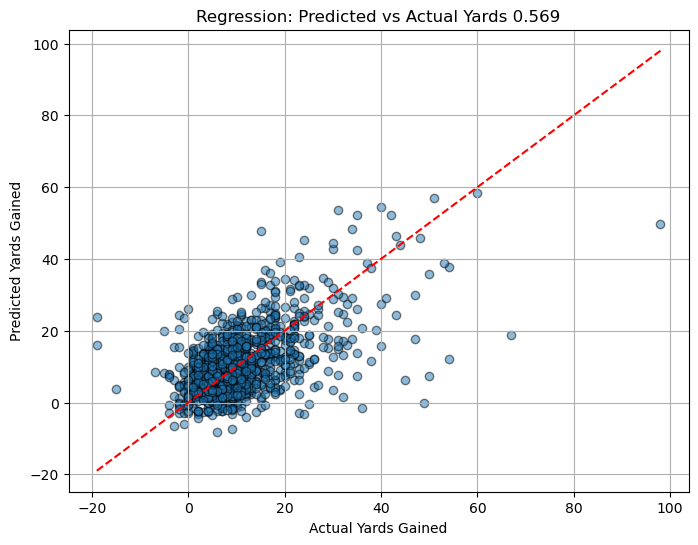

In [31]:

# plt.scatter(yr_test, yr_pred,s=1)

corr, _ = pearsonr(yr_test, yr_pred)


plt.figure(figsize=(8, 6))
plt.scatter(yr_test, yr_pred, alpha=0.5, edgecolors='k')
plt.plot([min(yr_test), max(yr_test)], [min(yr_test), max(yr_test)], 'r--')  # Ideal line
plt.xlabel("Actual Yards Gained")
plt.ylabel("Predicted Yards Gained")
plt.title(f"Regression: Predicted vs Actual Yards {corr:.3f}")
plt.grid(True)
plt.show()

(array([1108.,    0.,    0.,    0.,    0.,  449.,    0.,    0.,    0.,
          22.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

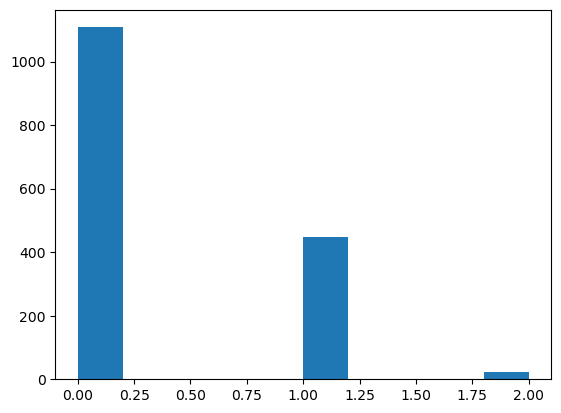

In [32]:
plt.hist(yc_pred)

In [33]:


class CustomNet(nn.Module):
    def __init__(self, input_dim, num_classes=5, dropout_rate=0.4):
        super(CustomNet, self).__init__()

        # Input -> 230
        self.input_layer = nn.Linear(input_dim, 230)
        self.bn0 = nn.BatchNorm1d(230)

        # 230 -> 256
        self.hidden_layer1 = nn.Linear(230, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(dropout_rate)

        # 256 -> 128
        self.hidden_layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Output layers
        self.class_output = nn.Linear(128, num_classes)
        self.reg_output = nn.Linear(128, 1)

        # Activations
        self.act = nn.LeakyReLU()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.bn0(x)
        
        x = self.act(self.hidden_layer1(x))
        x = self.bn1(x)
        x = self.dropout1(x)
        
        x = self.act(self.hidden_layer2(x))
        x = self.bn2(x)
        x = self.dropout2(x)
        
        class_output = self.class_output(x)
        reg_output = self.reg_output(x)

        return class_output, reg_output


model = CustomNet(input_dim=Xc_train.shape[1])
criterion_class = nn.CrossEntropyLoss()
criterion_reg = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)





In [34]:


# # Training loop
# for epoch in range(200):
#     model.train()
#     total_loss = 0
#     for X_batch, y_class, y_reg in train_loader:
#         optimizer.zero_grad()
        
#         # Forward pass
#         class_pred, reg_pred = model(X_batch)
        
#         # Compute losses
#         loss_class = criterion_class(class_pred, y_class)
#         loss_reg = criterion_reg(reg_pred, y_reg)
        
#         # Total loss (you can weight the losses differently if needed)
#         total_loss = loss_class + loss_reg
        
#         # Backward pass and optimization
#         total_loss.backward()
#         optimizer.step()
        
#     print(f"Epoch {epoch + 1}/{20}, Loss: {total_loss.item():.4f}")


In [35]:
# Assuming you have your training data in Xc_train, yc_train, Xr_train, yr_train
Xc_train_np = Xc_train.to_numpy() if hasattr(Xc_train, "to_numpy") else Xc_train
yc_train_np = yc_train.to_numpy() if hasattr(yc_train, "to_numpy") else yc_train
yr_train_np = yr_train.to_numpy() if hasattr(yr_train, "to_numpy") else yr_train
Xr_train_np = Xr_train.to_numpy() if hasattr(Xr_train, "to_numpy") else Xr_train


# Convert to torch tensors
Xc_train_tensor = torch.tensor(Xc_train_np, dtype=torch.float32)
Xr_train_tensor = torch.tensor(Xr_train_np, dtype=torch.float32)

yc_train_tensor = torch.tensor(yc_train_np, dtype=torch.long)  # For classification (long type)
yr_train_tensor = torch.tensor(yr_train_np, dtype=torch.float32).unsqueeze(1)  # For regression (float)

# Create DataLoader
clf_train_dataset = torch.utils.data.TensorDataset(Xc_train_tensor, yc_train_tensor)
clf_loader = torch.utils.data.DataLoader(clf_train_dataset, batch_size=64, shuffle=True)


# Regression DataLoader (only completions)
reg_dataset = torch.utils.data.TensorDataset(Xr_train_tensor, yr_train_tensor)
reg_loader = torch.utils.data.DataLoader(reg_dataset, batch_size=64, shuffle=True)

In [36]:
# Convert test data to numpy if needed
Xc_test_np = Xc_test.to_numpy() if hasattr(Xc_test, "to_numpy") else Xc_test
yc_test_np = yc_test.to_numpy() if hasattr(yc_test, "to_numpy") else yc_test

Xr_test_np = Xr_test.to_numpy() if hasattr(Xr_test, "to_numpy") else Xr_test
yr_test_np = yr_test.to_numpy() if hasattr(yr_test, "to_numpy") else yr_test

# Convert to torch tensors
Xc_test_tensor = torch.tensor(Xc_test_np, dtype=torch.float32)
yc_test_tensor = torch.tensor(yc_test_np, dtype=torch.long)

Xr_test_tensor = torch.tensor(Xr_test_np, dtype=torch.float32)
yr_test_tensor = torch.tensor(yr_test_np, dtype=torch.float32).unsqueeze(1)

# Create test datasets and dataloaders
clf_test_dataset = torch.utils.data.TensorDataset(Xc_test_tensor, yc_test_tensor)
clf_test_loader = torch.utils.data.DataLoader(clf_test_dataset, batch_size=64, shuffle=False)

reg_test_dataset = torch.utils.data.TensorDataset(Xr_test_tensor, yr_test_tensor)
reg_test_loader = torch.utils.data.DataLoader(reg_test_dataset, batch_size=64, shuffle=False)


In [37]:
type(yc_train)

numpy.ndarray

In [38]:

NUM_EPOCHS = 100
# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()

    total_loss_class = 0
    total_loss_reg = 0

    # Classification training
    for X_batch, y_batch in clf_loader:
        optimizer.zero_grad()
        class_pred, _ = model(X_batch)
        loss = criterion_class(class_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss_class += loss.item()

    # Regression training (only on completions)
    for X_batch, y_batch in reg_loader:
        optimizer.zero_grad()
        _, reg_pred = model(X_batch)
        loss = criterion_reg(reg_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss_reg += loss.item()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Class Loss: {total_loss_class:.4f} | Reg Loss: {total_loss_reg:.4f}")

Epoch 1/100 | Class Loss: 174.1387 | Reg Loss: 721.4522
Epoch 2/100 | Class Loss: 166.7024 | Reg Loss: 714.9591
Epoch 3/100 | Class Loss: 159.1909 | Reg Loss: 714.3126
Epoch 4/100 | Class Loss: 154.1331 | Reg Loss: 705.7568
Epoch 5/100 | Class Loss: 147.4661 | Reg Loss: 700.9770
Epoch 6/100 | Class Loss: 141.2212 | Reg Loss: 692.0874
Epoch 7/100 | Class Loss: 134.5458 | Reg Loss: 684.1672
Epoch 8/100 | Class Loss: 127.1014 | Reg Loss: 676.2048
Epoch 9/100 | Class Loss: 120.5145 | Reg Loss: 662.5285
Epoch 10/100 | Class Loss: 112.7541 | Reg Loss: 654.7348
Epoch 11/100 | Class Loss: 106.3219 | Reg Loss: 638.3649
Epoch 12/100 | Class Loss: 99.3726 | Reg Loss: 623.0323
Epoch 13/100 | Class Loss: 93.5888 | Reg Loss: 608.2604
Epoch 14/100 | Class Loss: 89.6157 | Reg Loss: 593.7405
Epoch 15/100 | Class Loss: 84.7445 | Reg Loss: 573.0004
Epoch 16/100 | Class Loss: 82.3216 | Reg Loss: 551.1776
Epoch 17/100 | Class Loss: 79.3783 | Reg Loss: 535.6576
Epoch 18/100 | Class Loss: 78.0153 | Reg Loss:

In [39]:
# Convert test sets to NumPy arrays if needed
Xc_test_np = Xc_test.to_numpy() if hasattr(Xc_test, "to_numpy") else Xc_test
yc_test_np = yc_test.to_numpy() if hasattr(yc_test, "to_numpy") else yc_test
yr_test_np = yr_test.to_numpy() if hasattr(yr_test, "to_numpy") else yr_test

# Convert to tensors
X_test_tensor = torch.tensor(Xc_test_np, dtype=torch.float32)
yc_test_tensor = torch.tensor(yc_test_np, dtype=torch.long)
yr_test_tensor = torch.tensor(yr_test_np, dtype=torch.float32).unsqueeze(1)


In [40]:
Xc_test_np = X_clf.to_numpy()
yc_test_np = y_clf_enc
yr_test_np = reg_df["yards_gained"].to_numpy()

print(Xc_test_np.shape)
print(yc_test_np.shape)
print(yr_test_np.shape)


(7895, 200)
(7895,)
(5299,)


In [41]:
model.eval()
total_correct = 0
total_class = 0
total_regression_loss = 0

# Lists to store classification outputs
all_probs_complete = []
all_probs_incomplete = []
all_probs_interception = []
all_true_completions = []
all_preds = []
all_labels = []

# ----- Classification Evaluation -----
with torch.no_grad():
    for X_batch, y_batch in clf_test_loader:
        class_logits, _ = model(X_batch)
        class_probs = torch.softmax(class_logits, dim=1)
        class_preds = torch.argmax(class_probs, dim=1)

        total_correct += (class_preds == y_batch).sum().item()
        total_class += y_batch.size(0)

        # Store probabilities for relevant classes
        all_probs_complete.append(class_probs[:, 0].cpu())
        all_probs_incomplete.append(class_probs[:, 1].cpu())
        all_probs_interception.append(class_probs[:, 2].cpu())
        all_preds.append(class_preds.cpu())
        all_labels.append(y_batch.cpu())

        # Store true labels for binary "complete" indicator
        all_true_completions.append((y_batch == 0).int().cpu())

classification_accuracy = total_correct / total_class

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Concatenate batched tensors
prob_complete = torch.cat(all_probs_complete).numpy()
prob_incomplete = torch.cat(all_probs_incomplete).numpy()
prob_interception = torch.cat(all_probs_interception).numpy()
true_complete = torch.cat(all_true_completions).numpy()

# ----- Regression Evaluation -----
all_r_preds = []
all_r_labels = []
with torch.no_grad():
    for X_batch, y_batch in reg_test_loader:
        _, reg_pred = model(X_batch)
        loss = criterion_reg(reg_pred, y_batch)
        total_regression_loss += loss.item() * X_batch.size(0)
        all_r_preds.append(reg_pred.cpu())
        all_r_labels.append(y_batch.cpu())

mse = total_regression_loss / len(reg_test_loader.dataset)
rmse = mse ** 0.5

all_r_preds = torch.cat(all_r_preds).numpy()
all_r_labels = torch.cat(all_r_labels).numpy()

# ----- Print results -----
print(f"Classification Accuracy: {classification_accuracy:.4f}")
print(f"Regression RMSE (only completions): {rmse:.2f} yards")


Classification Accuracy: 0.5915
Regression RMSE (only completions): 3.17 yards


In [42]:
all_r_labels.mean()

10.9537735

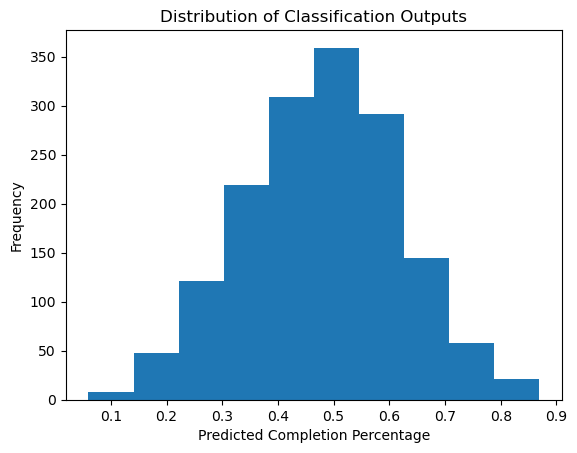

In [43]:
plt.hist(prob_complete)

plt.xlabel("Predicted Completion Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Classification Outputs")
plt.show()

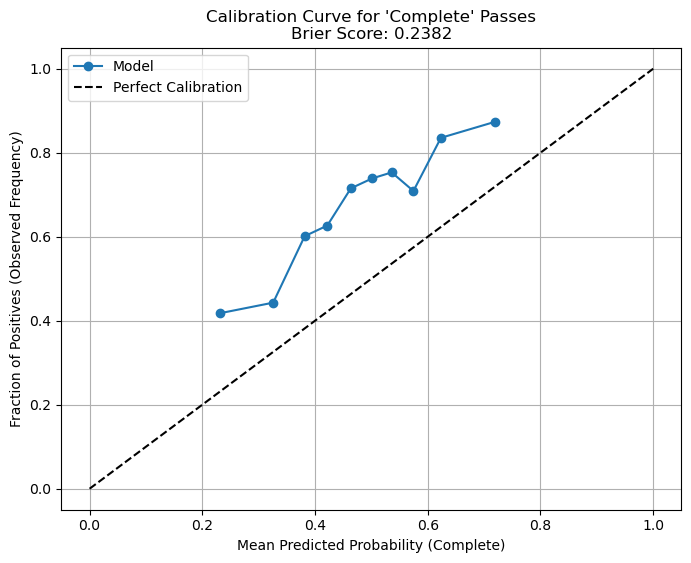

In [44]:


# Compute Brier score
brier = brier_score_loss(true_complete, prob_complete)

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    true_complete, prob_complete, 
    n_bins=10, 
    strategy='quantile'
)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "o-", label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability (Complete)")
plt.ylabel("Fraction of Positives (Observed Frequency)")
plt.title(f"Calibration Curve for 'Complete' Passes\nBrier Score: {brier:.4f}")
plt.legend()
plt.grid(True)
plt.show()


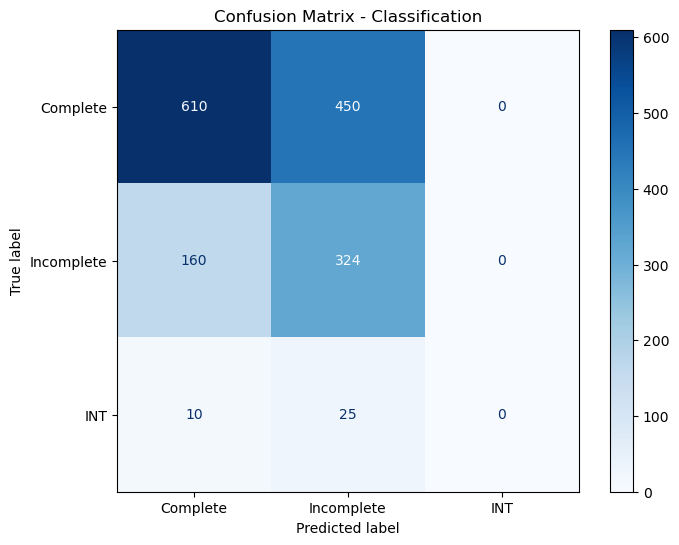

In [45]:


# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Complete", "Incomplete", "INT", ])# "Sack" "Run"

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Classification")
plt.show()


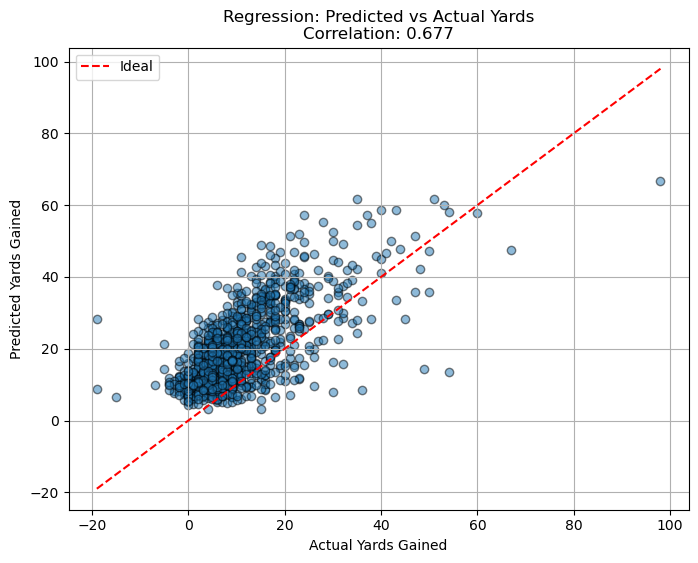

In [46]:


# Ensure both inputs are float NumPy arrays
labels = np.array(all_r_labels, dtype=np.float32).flatten()
preds = np.array(all_r_preds, dtype=np.float32).flatten()

# Compute Pearson correlation
corr, _ = pearsonr(labels, preds)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(labels, preds, alpha=0.5, edgecolors='k')
plt.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--', label="Ideal")
plt.xlabel("Actual Yards Gained")
plt.ylabel("Predicted Yards Gained")
plt.title(f"Regression: Predicted vs Actual Yards\nCorrelation: {corr:.3f}")
plt.legend()
plt.grid(True)
plt.show()
